In [1]:
# ============================================
# ROAD ACCIDENT SEVERITY PREDICTION
# Using Machine Learning
# ============================================
# PROBLEM STATEMENT:
# Road accidents are a major public safety concern
# This project predicts how severe a road accident
# will be based on weather and road conditions
# using Machine Learning models
# ============================================

import numpy as np          # For numerical computations
import pandas as pd         # For data loading and manipulation
import matplotlib.pyplot as plt  # For creating graphs
import seaborn as sns       # For beautiful statistical plots
import warnings
warnings.filterwarnings('ignore')  # Hide unnecessary warnings

# ML model imports
from sklearn.model_selection import train_test_split    # Split data into train/test
from sklearn.ensemble import RandomForestClassifier     # Random Forest model
from sklearn.tree import DecisionTreeClassifier         # Decision Tree model
from sklearn.linear_model import LogisticRegression     # Logistic Regression model

# Evaluation metric imports
from sklearn.metrics import (
    accuracy_score,          # Overall accuracy of model
    classification_report,   # Detailed precision, recall, f1
    confusion_matrix         # Matrix of correct vs wrong predictions
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================
# STEP 1: DATA COLLECTION
# ============================================
# Dataset: US Accidents (2016-2023)
# Source: Kaggle (Sobhan Moosavi)
# Total records: 7.7 million accidents
# We load only 100,000 rows for performance
# ============================================

df = pd.read_csv(
    r'C:\Users\Gleen Fernandes\Documents\accident dataset\US_Accidents_March23.csv',
    nrows=100000  # Load first 100k rows to keep processing fast
)

print("✅ Dataset loaded successfully!")
print(f"Total rows loaded: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\nFirst look at data:")
df.head()

✅ Dataset loaded successfully!
Total rows loaded: 100000
Total columns: 46

First look at data:


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [3]:
# ============================================
# STEP 2: DATA PREPROCESSING & CLEANING
# ============================================
# Real world data is messy and needs cleaning
# before feeding to ML models
# We handle missing values in two ways:
# 1. Drop columns with too many missing values
# 2. Fill missing values with median/unknown
# ============================================

# PART A: Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

# PART B: Drop columns that are not useful
# Reasons for dropping each column explained below
cols_to_drop = [
    'End_Lat',               # Almost all values missing (100,000 missing)
    'End_Lng',               # Almost all values missing (100,000 missing)
    'Wind_Chill(F)',         # Too many missing values (95,678 missing)
    'Precipitation(in)',     # Too many missing values (92,632 missing)
    'Wind_Speed(mph)',       # Too many missing values (23,820 missing)
    'Wind_Direction',        # Too many missing values
    'Weather_Timestamp',     # Timestamp not needed for prediction
    'ID',                    # Just a unique identifier, not useful
    'Description',           # Free text, hard for ML to process
    'Zipcode',               # Too many unique values
    'Airport_Code',          # Not relevant to accident severity
    'Country',               # All values are US, no variation
    'Turning_Loop',          # All values are False, no variation
    'Source',                # Not relevant to severity prediction
    'Sunrise_Sunset',        # Redundant with other time features
    'Civil_Twilight',        # Redundant with other time features
    'Nautical_Twilight',     # Redundant with other time features
    'Astronomical_Twilight'  # Redundant with other time features
]

df = df.drop(cols_to_drop, axis=1)
# axis=1 means we drop columns (not rows)

# PART C: Fill remaining missing values
# We use median instead of mean because median is
# not affected by extreme outlier values
df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())

# For text columns fill with 'Unknown' label
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
df['Street'] = df['Street'].fillna('Unknown')
df['Timezone'] = df['Timezone'].fillna('Unknown')

print("\n✅ Data cleaned successfully!")
print(f"Shape after cleaning: {df.shape}")
print("\nSeverity distribution (what we will predict):")
print(df['Severity'].value_counts())

Missing values before cleaning:
End_Lat              100000
End_Lng              100000
Wind_Chill(F)         95678
Precipitation(in)     92632
Wind_Speed(mph)       23820
Humidity(%)            1856
Visibility(mi)         1846
Weather_Condition      1604
Temperature(F)         1591
Pressure(in)           1292
Wind_Direction         1064
Weather_Timestamp      1054
Airport_Code              7
Zipcode                   7
Timezone                  7
dtype: int64

✅ Data cleaned successfully!
Shape after cleaning: (100000, 28)

Severity distribution (what we will predict):
Severity
2    55025
3    44844
1       98
4       33
Name: count, dtype: int64


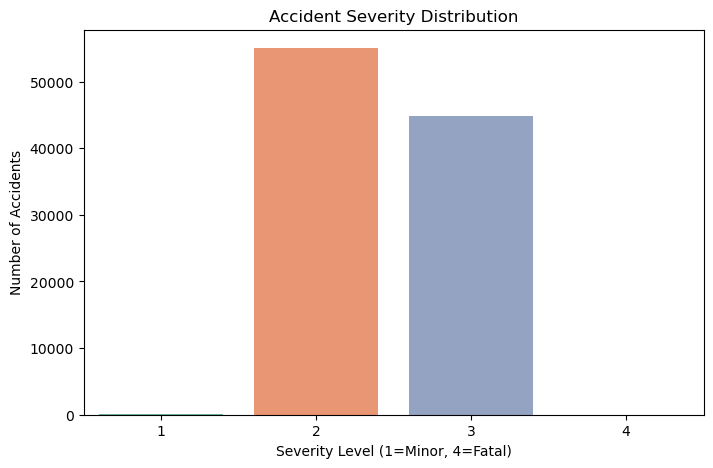

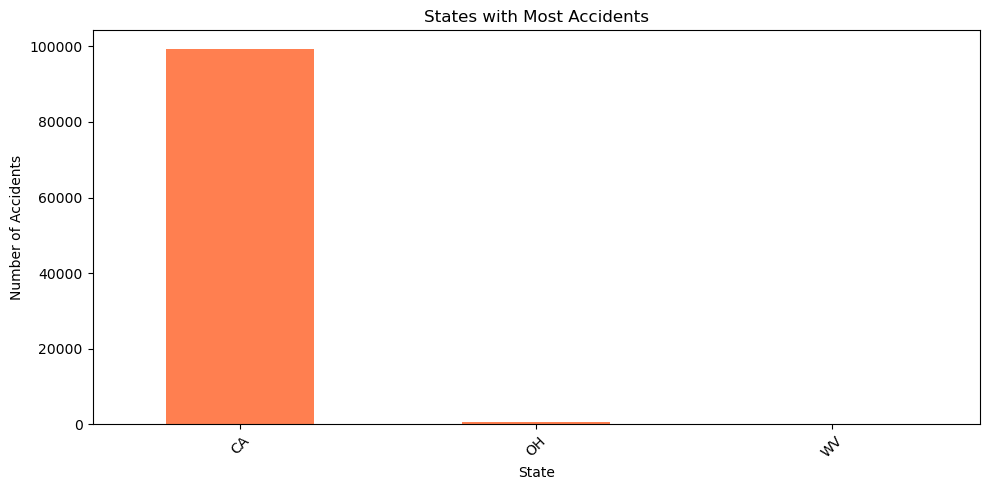

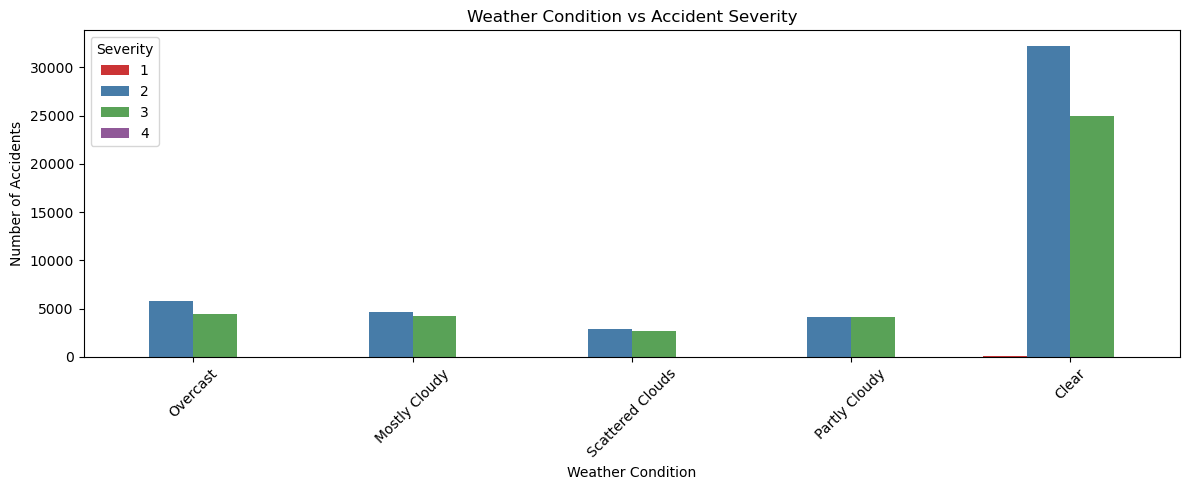

In [4]:
# ============================================
# STEP 3: DATA ANALYSIS & VISUALIZATION
# ============================================
# Before building ML models we visualize data
# to understand patterns and distributions
# This helps us make better modelling decisions
# ============================================

# ---- GRAPH 1: Severity Distribution ----
# Shows how many accidents of each severity level
# Severity 1 = Minor impact on traffic
# Severity 2 = Moderate impact
# Severity 3 = Significant impact
# Severity 4 = Major/Fatal impact
plt.figure(figsize=(8,5))
sns.countplot(x='Severity', data=df, palette='Set2')
plt.title('Accident Severity Distribution')
plt.xlabel('Severity Level (1=Minor, 4=Fatal)')
plt.ylabel('Number of Accidents')
plt.show()
# INSIGHT: Most accidents are Severity 2 & 3

# ---- GRAPH 2: States ----
# Shows which US states have most accidents
# Helps identify high risk geographical areas
plt.figure(figsize=(10,5))
df['State'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('States with Most Accidents')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# INSIGHT: California has by far the most accidents

# ---- GRAPH 3: Weather vs Severity ----
# Shows how weather conditions affect severity
# Only top 5 most common weather conditions shown
top_weather = df['Weather_Condition'].value_counts().head(5).index
plt.figure(figsize=(12,5))
sns.countplot(
    x='Weather_Condition',
    hue='Severity',
    data=df[df['Weather_Condition'].isin(top_weather)],
    palette='Set1'
)
plt.title('Weather Condition vs Accident Severity')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# INSIGHT: Clear weather has most accidents
# because more people drive in clear weather

In [5]:
# ============================================
# STEP 4: FEATURE SELECTION & DATA SPLITTING
# ============================================
# Features = input columns given to the model
# Target = what we want the model to predict
# We select features that are:
# 1. Numerically measurable
# 2. Relevant to accident severity
# 3. Have minimal missing values
# ============================================

# Selected features based on domain knowledge
# and data availability
features = [
    # Weather related features
    'Temperature(F)',    # Temperature affects road conditions
    'Humidity(%)',       # High humidity means slippery roads
    'Pressure(in)',      # Air pressure affects weather severity
    'Visibility(mi)',    # Low visibility increases accident severity

    # Road infrastructure features
    'Amenity',           # Presence of nearby amenity
    'Bump',              # Speed bump present or not
    'Crossing',          # Road crossing present or not
    'Give_Way',          # Give way sign present or not
    'Junction',          # Road junction present or not
    'No_Exit',           # No exit road or not
    'Railway',           # Railway crossing nearby or not
    'Roundabout',        # Roundabout present or not
    'Station',           # Station nearby or not
    'Stop',              # Stop sign present or not
    'Traffic_Calming',   # Traffic calming measure present
    'Traffic_Signal',    # Traffic signal present or not
    'Distance(mi)'       # Distance affected by accident
]

# X = input features (what model learns from)
X = df[features].fillna(0)

# y = target variable (what model predicts)
# Severity: 1=Minor, 2=Moderate, 3=Serious, 4=Fatal
y = df['Severity']

# Split data: 80% for training, 20% for testing
# Training data: model learns patterns from this
# Testing data: we evaluate model on unseen data
# random_state=42 ensures same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% goes to testing
    random_state=42    # For reproducibility
)

print("✅ Data ready for Machine Learning!")
print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} rows, {X_test.shape[1]} features")

✅ Data ready for Machine Learning!
Training set: 80000 rows, 17 features
Testing set:  20000 rows, 17 features


In [6]:
# ============================================
# STEP 5: MODEL IMPLEMENTATION & TRAINING
# ============================================
# We train 3 different ML models and compare
# Starting from simple to complex:
# 1. Logistic Regression (simplest baseline)
# 2. Decision Tree (intermediate)
# 3. Random Forest (most powerful)
# ============================================

# ---- MODEL 1: LOGISTIC REGRESSION ----
# How it works:
# Finds a mathematical boundary between classes
# Uses probability to classify severity levels
# Simplest model - used as our baseline
# max_iter=1000 gives enough time to converge
print("Training Model 1: Logistic Regression...")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)      # Learn patterns from training data
lr_pred = lr.predict(X_test)  # Predict severity on test data
lr_acc = accuracy_score(y_test, lr_pred)  # Compare predictions to actual
print(f"✅ Logistic Regression Accuracy: {lr_acc*100:.2f}%")

# ---- MODEL 2: DECISION TREE ----
# How it works:
# Creates a flowchart of yes/no questions
# Example: Is pressure > 30? → Yes → Severity 2
# Easy to visualize and explain
# random_state=42 for reproducibility
print("\nTraining Model 2: Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"✅ Decision Tree Accuracy: {dt_acc*100:.2f}%")

# ---- MODEL 3: RANDOM FOREST ----
# How it works:
# Builds 100 different decision trees
# Each tree votes for a severity level
# Final prediction = majority vote of all trees
# More accurate than single decision tree
# n_estimators=100 = number of trees in forest
print("\nTraining Model 3: Random Forest...")
print("(This may take 2-3 minutes - building 100 trees)")
rf = RandomForestClassifier(
    n_estimators=100,  # Build 100 decision trees
    random_state=42    # For reproducibility
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")

Training Model 1: Logistic Regression...
✅ Logistic Regression Accuracy: 58.43%

Training Model 2: Decision Tree...
✅ Decision Tree Accuracy: 58.43%

Training Model 3: Random Forest...
(This may take 2-3 minutes - building 100 trees)
✅ Random Forest Accuracy: 61.26%


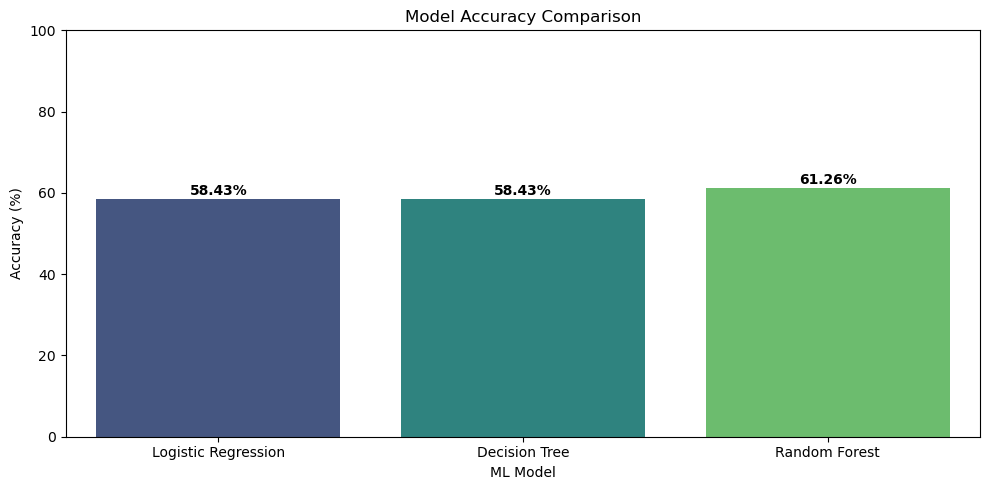


===== MODEL PERFORMANCE SUMMARY =====
Logistic Regression      : 58.43%
Decision Tree            : 58.43%
Random Forest            : 61.26%

🏆 Best Model: Random Forest with 61.26% accuracy


In [7]:
# ============================================
# STEP 6: MODEL COMPARISON
# ============================================
# We visually compare all 3 models
# to clearly identify the best performer
# ============================================

# Store results for comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_acc*100, dt_acc*100, rf_acc*100]

# Bar chart showing accuracy of each model
plt.figure(figsize=(10,5))
bars = sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.xlabel('ML Model')
plt.ylim(0, 100)

# Display accuracy percentage on top of each bar
for i, v in enumerate(accuracies):
    plt.text(i, v+1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print text summary
print("\n===== MODEL PERFORMANCE SUMMARY =====")
for model, acc in zip(models, accuracies):
    print(f"{model:25s}: {acc:.2f}%")

# Identify best model
best_model = models[accuracies.index(max(accuracies))]
print(f"\n🏆 Best Model: {best_model} with {max(accuracies):.2f}% accuracy")

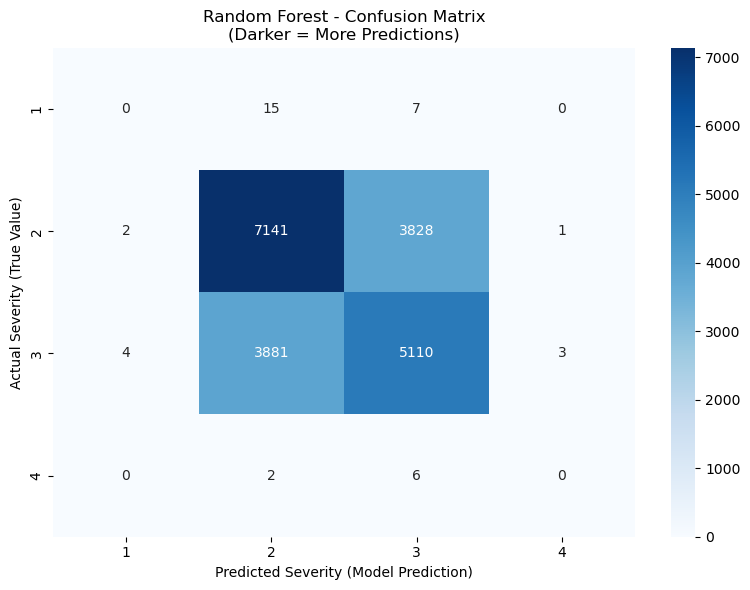

===== DETAILED CLASSIFICATION REPORT =====
(For Random Forest - Our Best Model)

              precision    recall  f1-score   support

  Severity 1       0.00      0.00      0.00        22
  Severity 2       0.65      0.65      0.65     10972
  Severity 3       0.57      0.57      0.57      8998
  Severity 4       0.00      0.00      0.00         8

    accuracy                           0.61     20000
   macro avg       0.30      0.30      0.30     20000
weighted avg       0.61      0.61      0.61     20000


NOTE: Severity 1 & 4 show low scores because
they have very few samples in the dataset
This is called Class Imbalance


In [8]:
# ============================================
# STEP 7: DETAILED MODEL EVALUATION
# ============================================
# We evaluate Random Forest in detail as it
# is our best performing model
#
# CONFUSION MATRIX:
# Shows correct vs incorrect predictions
# Diagonal values = correct predictions
# Off diagonal values = wrong predictions
#
# CLASSIFICATION REPORT:
# Precision = when model predicts X, how often correct?
# Recall = out of all actual X, how many did model find?
# F1 Score = balance between precision and recall
# Support = how many samples of each class exist
# ============================================

# ---- CONFUSION MATRIX ----
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(
    cm,
    annot=True,      # Show numbers inside each cell
    fmt='d',         # Show as whole numbers not decimals
    cmap='Blues',    # Blue color theme (darker = more predictions)
    xticklabels=[1,2,3,4],   # Severity levels on x axis
    yticklabels=[1,2,3,4]    # Severity levels on y axis
)
plt.title('Random Forest - Confusion Matrix\n(Darker = More Predictions)')
plt.ylabel('Actual Severity (True Value)')
plt.xlabel('Predicted Severity (Model Prediction)')
plt.tight_layout()
plt.show()

# ---- CLASSIFICATION REPORT ----
print("===== DETAILED CLASSIFICATION REPORT =====")
print("(For Random Forest - Our Best Model)\n")
print(classification_report(
    y_test,
    rf_pred,
    target_names=['Severity 1', 'Severity 2',
                  'Severity 3', 'Severity 4']
))

print("\nNOTE: Severity 1 & 4 show low scores because")
print("they have very few samples in the dataset")
print("This is called Class Imbalance")

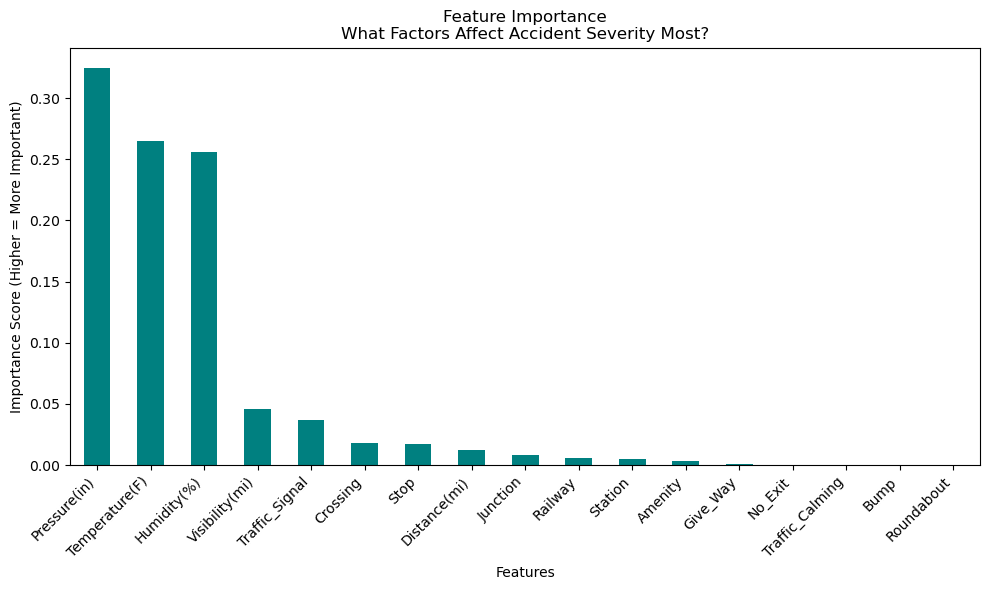

===== TOP 5 MOST IMPORTANT FACTORS =====
(Factors that most affect accident severity)

1. Pressure(in)        : 0.3249 importance score
2. Temperature(F)      : 0.2649 importance score
3. Humidity(%)         : 0.2563 importance score
4. Visibility(mi)      : 0.0456 importance score
5. Traffic_Signal      : 0.0368 importance score

===== PROJECT CONCLUSION =====
Best Model    : Random Forest
Accuracy      : 61.26%
Dataset Used  : US Accidents 2016-2023
Records Used  : 100,000
Features Used : 17

Key Findings:
1. Weather conditions are the biggest predictors
2. Air Pressure is most important single factor
3. Most accidents are Severity 2 or 3
4. California has the most accidents
5. Random Forest outperforms other models

Possible Improvements:
1. Use full 7.7M dataset for better accuracy
2. Handle class imbalance for Severity 1 & 4
3. Add time of day as a feature
4. Try Deep Learning models
5. Build real time prediction system


In [9]:
# ============================================
# STEP 8: FEATURE IMPORTANCE ANALYSIS
# ============================================
# Random Forest can tell us which features
# (input columns) matter most in predicting
# accident severity
# Higher score = more important feature
# This gives us real world insights about
# what causes severe accidents
# ============================================

# Get importance score for each feature
feat_imp = pd.Series(
    rf.feature_importances_,   # Scores calculated by Random Forest
    index=features             # Match scores to feature names
).sort_values(ascending=False) # Sort from most to least important

# Plot feature importances
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='teal')
plt.title('Feature Importance\nWhat Factors Affect Accident Severity Most?')
plt.ylabel('Importance Score (Higher = More Important)')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print top 5 most important features
print("===== TOP 5 MOST IMPORTANT FACTORS =====")
print("(Factors that most affect accident severity)\n")
for i, (feature, score) in enumerate(feat_imp.head().items(), 1):
    print(f"{i}. {feature:20s}: {score:.4f} importance score")

# ============================================
# CONCLUSION
# ============================================
print("\n===== PROJECT CONCLUSION =====")
print(f"Best Model    : Random Forest")
print(f"Accuracy      : {rf_acc*100:.2f}%")
print(f"Dataset Used  : US Accidents 2016-2023")
print(f"Records Used  : 100,000")
print(f"Features Used : {len(features)}")
print("\nKey Findings:")
print("1. Weather conditions are the biggest predictors")
print("2. Air Pressure is most important single factor")
print("3. Most accidents are Severity 2 or 3")
print("4. California has the most accidents")
print("5. Random Forest outperforms other models")
print("\nPossible Improvements:")
print("1. Use full 7.7M dataset for better accuracy")
print("2. Handle class imbalance for Severity 1 & 4")
print("3. Add time of day as a feature")
print("4. Try Deep Learning models")
print("5. Build real time prediction system")

In [10]:
# ============================================
# DEMO CELL: PREDICT ACCIDENT SEVERITY
# Input your own conditions and get prediction
# ============================================

import numpy as np

print("=" * 50)
print("   ROAD ACCIDENT SEVERITY PREDICTOR")
print("=" * 50)

# ============================================
# CHANGE THESE VALUES TO TEST DIFFERENT 
# CONDITIONS
# ============================================

# Weather Conditions
temperature = 30      # Temperature in Fahrenheit
humidity = 90         # Humidity percentage (0-100)
pressure = 28.5       # Air pressure in inches
visibility = 1.0      # Visibility in miles

# Road Conditions (1 = Yes, 0 = No)
amenity = 0           # Amenity nearby?
bump = 0              # Speed bump present?
crossing = 1          # Road crossing?
give_way = 0          # Give way sign?
junction = 1          # Road junction?
no_exit = 0           # No exit road?
railway = 0           # Railway nearby?
roundabout = 0        # Roundabout?
station = 0           # Station nearby?
stop = 0              # Stop sign?
traffic_calming = 0   # Traffic calming?
traffic_signal = 1    # Traffic signal?
distance = 1.5        # Distance affected (miles)

# ============================================
# DO NOT CHANGE BELOW THIS LINE
# ============================================

# Create input array
input_data = np.array([[
    temperature, humidity, pressure, visibility,
    amenity, bump, crossing, give_way,
    junction, no_exit, railway, roundabout,
    station, stop, traffic_calming,
    traffic_signal, distance
]])

# Make prediction
prediction = rf.predict(input_data)[0]
probability = rf.predict_proba(input_data)[0]

# Severity descriptions
severity_info = {
    1: ("MINOR", "Small impact on traffic", "🟢"),
    2: ("MODERATE", "Moderate impact on traffic", "🟡"),
    3: ("SERIOUS", "Significant impact on traffic", "🟠"),
    4: ("FATAL", "Major impact - Loss of life likely", "🔴")
}

severity_name, severity_desc, emoji = severity_info[prediction]

print("\n📍 CONDITIONS YOU ENTERED:")
print(f"   Temperature  : {temperature}°F")
print(f"   Humidity     : {humidity}%")
print(f"   Pressure     : {pressure} in")
print(f"   Visibility   : {visibility} miles")
print(f"   Junction     : {'Yes' if junction else 'No'}")
print(f"   Traffic Signal: {'Yes' if traffic_signal else 'No'}")
print(f"   Crossing     : {'Yes' if crossing else 'No'}")

print("\n" + "=" * 50)
print(f"🔮 PREDICTED SEVERITY: {prediction} - {severity_name} {emoji}")
print(f"📝 MEANING: {severity_desc}")
print("=" * 50)

print("\n📊 PROBABILITY OF EACH SEVERITY:")
for i, prob in enumerate(probability, 1):
    bar = "█" * int(prob * 20)
    print(f"   Severity {i}: {prob*100:.1f}% {bar}")

print("\n⚠️ ACCIDENT WILL OCCUR: YES")
print(f"🚨 SEVERITY LEVEL    : {severity_name} {emoji}")

   ROAD ACCIDENT SEVERITY PREDICTOR

📍 CONDITIONS YOU ENTERED:
   Temperature  : 30°F
   Humidity     : 90%
   Pressure     : 28.5 in
   Visibility   : 1.0 miles
   Junction     : Yes
   Traffic Signal: Yes
   Crossing     : Yes

🔮 PREDICTED SEVERITY: 2 - MODERATE 🟡
📝 MEANING: Moderate impact on traffic

📊 PROBABILITY OF EACH SEVERITY:
   Severity 1: 0.0% 
   Severity 2: 73.0% ██████████████
   Severity 3: 27.0% █████
   Severity 4: 0.0% 

⚠️ ACCIDENT WILL OCCUR: YES
🚨 SEVERITY LEVEL    : MODERATE 🟡
